In [1]:
%matplotlib inline

In [2]:
import re
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from torch.utils.data import DataLoader

from anomalib import TaskType
from anomalib.data import Folder, PredictDataset
from anomalib.engine import Engine
from anomalib.models import Padim, Patchcore

In [3]:
DATA = Path("data/bolt_roi")
IMAGE_SIZE = (256, 720)

# explicit Resize+Normalize only, no crop. anomalib's per-model configure_transforms()
# defaults differ (PatchCore silently adds a CenterCrop, PaDiM doesn't), which would
# discard part of the ROI depending on which model you use. Pass this explicitly to
# every Folder(...) call below so both models see the identical, full ROI.
from torchvision.transforms import v2
TRANSFORM = v2.Compose([
    v2.Resize(IMAGE_SIZE, antialias=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = Path("results/bolt") / RUN_ID
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR

WindowsPath('results/bolt/20260831_154724')

In [4]:
datamodule = Folder(
    name="bolt",
    normal_dir=DATA / "train",
    task=TaskType.CLASSIFICATION,
    train_batch_size=8,
    eval_batch_size=8,
    num_workers=0,
    image_size=IMAGE_SIZE,
    transform=TRANSFORM,
    test_split_mode="none",
    val_split_mode="none",
)

model = Padim(
    backbone="resnet18",
    layers=["layer1", "layer2", "layer3"],
    n_features=100,
)

engine = Engine(
    max_epochs=1,
    accelerator="auto",
    normalization="none",
    default_root_dir=str(OUT_DIR),
    logger=False,
    limit_val_batches=0,
)

In [5]:
engine.fit(model=model, datamodule=datamodule)

ckpt_path = next(OUT_DIR.rglob("*.ckpt"))
print(f"checkpoint: {ckpt_path}")

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


`Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..


You are using a CUDA device ('NVIDIA GeForce RTX 3080') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


...

Output()

C:\miniconda3\envs\aio\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
C:\miniconda3\envs\aio\Lib\site-packages\lightning\pytorch\loops\fit_loop.py:538: Found 69 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


C:\miniconda3\envs\aio\Lib\site-packages\lightning\pytorch\loops\optimization\automatic.py:134: `training_step` 
returned `None`. If this was on purpose, ignore this warning...

`Trainer.fit` stopped: `max_epochs=1` reached.


checkpoint: results\bolt\20260831_154724\Padim\bolt\v0\weights\lightning\model.ckpt


In [6]:
def part_id_from_filename(path: Path) -> str:
    m = re.search(r"_p(\d+)_", path.name)
    return f"p{m.group(1)}" if m else path.stem


def score_folder(engine: Engine, model, folder: Path) -> pd.DataFrame:
    dataset = PredictDataset(path=folder, image_size=IMAGE_SIZE)
    loader = DataLoader(dataset, batch_size=8, num_workers=0)
    predictions = engine.predict(model=model, dataloaders=loader)

    rows = []
    for batch in predictions:
        for path, score in zip(batch["image_path"], batch["pred_scores"]):
            p = Path(path)
            rows.append({"file": p.name, "part_id": part_id_from_filename(p), "score": float(score)})
    return pd.DataFrame(rows)

In [7]:
scores_heldout = score_folder(engine, model, DATA / "heldout")
scores_surface = score_folder(engine, model, DATA / "defects" / "surface")
scores_thread = score_folder(engine, model, DATA / "defects" / "thread")

scores_heldout.to_csv(OUT_DIR / "scores_heldout.csv", index=False)
scores_surface.to_csv(OUT_DIR / "scores_defects_surface.csv", index=False)
scores_thread.to_csv(OUT_DIR / "scores_defects_thread.csv", index=False)

print(f"heldout: {len(scores_heldout)} frames / {scores_heldout.part_id.nunique()} parts")
print(f"surface: {len(scores_surface)} frames / {scores_surface.part_id.nunique()} parts")
print(f"thread:  {len(scores_thread)} frames / {scores_thread.part_id.nunique()} parts")
print(f"\nrun output: {OUT_DIR}")

ckpt_path is not provided. Model weights will not be loaded.


F1Score class exists for backwards compatibility. It will be removed in v1.1. Please use BinaryF1Score from torchmetrics instead


F1Score class exists for backwards compatibility. It will be removed in v1.1. Please use BinaryF1Score from torchmetrics instead


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

...

F1Score class exists for backwards compatibility. It will be removed in v1.1. Please use BinaryF1Score from torchmetrics instead


F1Score class exists for backwards compatibility. It will be removed in v1.1. Please use BinaryF1Score from torchmetrics instead


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

heldout: 48 frames / 24 parts
surface: 41 frames / 14 parts
thread:  39 frames / 13 parts

run output: results\bolt\20260831_154724


In [8]:
from sklearn.metrics import roc_auc_score


def auroc(normal_scores, defect_scores):
    y = [0] * len(normal_scores) + [1] * len(defect_scores)
    s = list(normal_scores) + list(defect_scores)
    return roc_auc_score(y, s)


print(f"n_features=100  surface={auroc(scores_heldout.score, scores_surface.score):.3f}  "
      f"thread={auroc(scores_heldout.score, scores_thread.score):.3f}")

n_features=100  surface=0.621  thread=0.364


In [9]:
import random


def fit_padim(seed: int) -> tuple[Engine, Padim]:
    random.seed(seed)
    torch.manual_seed(seed)
    dm = Folder(
        name="bolt", normal_dir=DATA / "train", task=TaskType.CLASSIFICATION,
        train_batch_size=8, eval_batch_size=8, num_workers=0,
        image_size=IMAGE_SIZE, transform=TRANSFORM,
        test_split_mode="none", val_split_mode="none",
    )
    m = Padim(backbone="resnet18", layers=["layer1", "layer2", "layer3"], n_features=100)
    e = Engine(max_epochs=1, accelerator="auto", normalization="none",
               default_root_dir=str(OUT_DIR / "seed_sweep" / str(seed)),
               logger=False, limit_val_batches=0, enable_progress_bar=False)
    e.fit(model=m, datamodule=dm)
    return e, m


padim_seeds = [0, 1, 2, 42]
padim_sweep = []
for seed in padim_seeds:
    e, m = fit_padim(seed)
    h = score_folder(e, m, DATA / "heldout").score
    s = score_folder(e, m, DATA / "defects" / "surface").score
    t = score_folder(e, m, DATA / "defects" / "thread").score
    padim_sweep.append({"seed": seed, "surface": auroc(h, s), "thread": auroc(h, t)})

padim_sweep = pd.DataFrame(padim_sweep)
padim_sweep

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


`Trainer(val_check_interval=1.0)` was configured so validation will run at the end of the training epoch..


F1Score class exists for backwards compatibility. It will be removed in v1.1. Please use BinaryF1Score from torchmetrics instead


...

ckpt_path is not provided. Model weights will not be loaded.


F1Score class exists for backwards compatibility. It will be removed in v1.1. Please use BinaryF1Score from torchmetrics instead


F1Score class exists for backwards compatibility. It will be removed in v1.1. Please use BinaryF1Score from torchmetrics instead


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


,seed,surface,thread
0,0,0.531504,0.239316
1,1,0.498984,0.276175
2,2,0.597561,0.371795
3,42,0.628557,0.408120


In [10]:
random.seed(0)
torch.manual_seed(0)

pc_datamodule = Folder(
    name="bolt", normal_dir=DATA / "train", task=TaskType.CLASSIFICATION,
    train_batch_size=8, eval_batch_size=8, num_workers=0,
    image_size=IMAGE_SIZE, transform=TRANSFORM,
    test_split_mode="none", val_split_mode="none",
)
pc_model = Patchcore(backbone="resnet18", layers=["layer2", "layer3"], coreset_sampling_ratio=0.02)
pc_engine = Engine(max_epochs=1, accelerator="auto", normalization="none",
                    default_root_dir=str(OUT_DIR / "patchcore_spike"),
                    logger=False, limit_val_batches=0, enable_progress_bar=False)
pc_engine.fit(model=pc_model, datamodule=pc_datamodule)

pc_heldout = score_folder(pc_engine, pc_model, DATA / "heldout").score
pc_surface = score_folder(pc_engine, pc_model, DATA / "defects" / "surface").score
pc_thread = score_folder(pc_engine, pc_model, DATA / "defects" / "thread").score

print(f"PatchCore  surface={auroc(pc_heldout, pc_surface):.3f}  thread={auroc(pc_heldout, pc_thread):.3f}")

GPU available: True (cuda), used: True


TPU available: False, using: 0 TPU cores


💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


F1Score class exists for backwards compatibility. It will be removed in v1.1. Please use BinaryF1Score from torchmetrics instead


F1Score class exists for backwards compatibility. It will be removed in v1.1. Please use BinaryF1Score from torchmetrics instead


...

ckpt_path is not provided. Model weights will not be loaded.


F1Score class exists for backwards compatibility. It will be removed in v1.1. Please use BinaryF1Score from torchmetrics instead


F1Score class exists for backwards compatibility. It will be removed in v1.1. Please use BinaryF1Score from torchmetrics instead


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


PatchCore  surface=0.987  thread=0.835


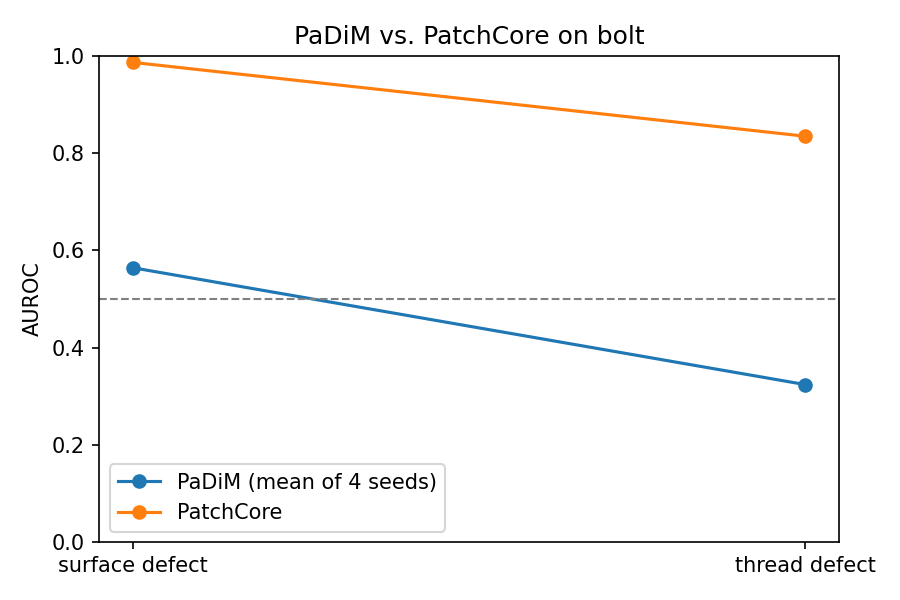

In [11]:
from IPython.display import Image, display

padim_mean = [padim_sweep["surface"].mean(), padim_sweep["thread"].mean()]
patchcore_vals = [auroc(pc_heldout, pc_surface), auroc(pc_heldout, pc_thread)]

x = ["surface defect", "thread defect"]
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, padim_mean, marker="o", label="PaDiM (mean of 4 seeds)")
ax.plot(x, patchcore_vals, marker="o", label="PatchCore")
ax.axhline(0.5, linestyle="--", color="gray", linewidth=1)

ax.set_ylabel("AUROC")
ax.set_ylim(0, 1)
ax.set_title("PaDiM vs. PatchCore on bolt")
ax.legend()

plt.tight_layout()
chart_path = OUT_DIR / "padim_vs_patchcore.png"
plt.savefig(chart_path, dpi=150)
plt.close(fig)
display(Image(filename=str(chart_path)))

ckpt_path is not provided. Model weights will not be loaded.


F1Score class exists for backwards compatibility. It will be removed in v1.1. Please use BinaryF1Score from torchmetrics instead


F1Score class exists for backwards compatibility. It will be removed in v1.1. Please use BinaryF1Score from torchmetrics instead


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Output()

C:\miniconda3\envs\aio\Lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.


ckpt_path is not provided. Model weights will not be loaded.


F1Score class exists for backwards compatibility. It will be removed in v1.1. Please use BinaryF1Score from torchmetrics instead


F1Score class exists for backwards compatibility. It will be removed in v1.1. Please use BinaryF1Score from torchmetrics instead


LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


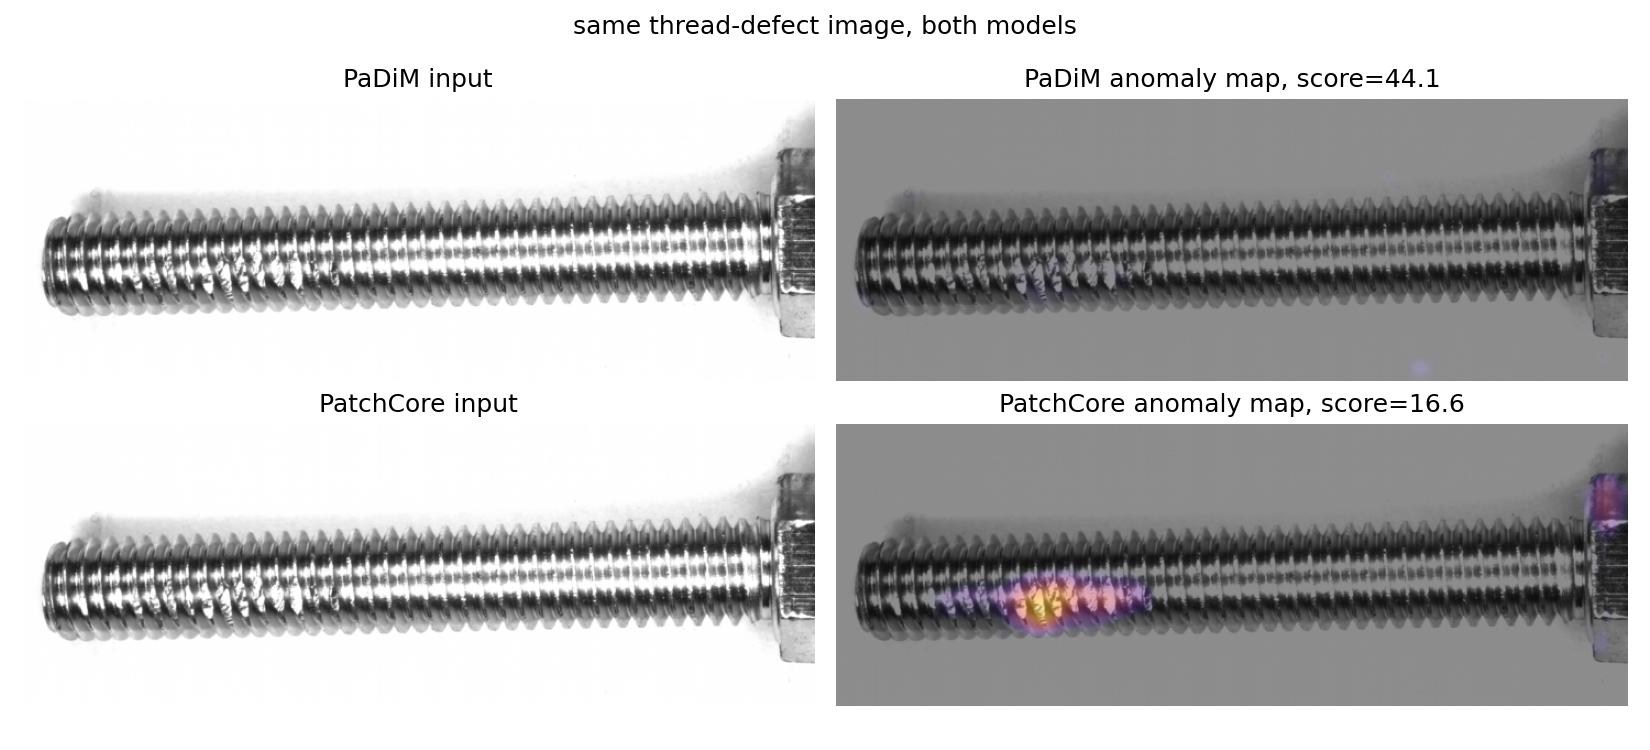

In [12]:
IMAGENET_MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
IMAGENET_STD = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


def denormalize(img_tensor):
    img = img_tensor.cpu() * IMAGENET_STD + IMAGENET_MEAN
    return img.clamp(0, 1).permute(1, 2, 0).numpy()


def predict_one(engine, model, image_path):
    dataset = PredictDataset(path=image_path, image_size=IMAGE_SIZE)
    loader = DataLoader(dataset, batch_size=1, num_workers=0)
    batch = engine.predict(model=model, dataloaders=loader)[0]
    return batch["image"][0], batch["anomaly_maps"][0].squeeze(), float(batch["pred_scores"][0])


sample_path = DATA / "defects" / "thread" / "bolt_defect_thread_p03_r1_A.png"

padim_img, padim_map, padim_score = predict_one(engine, model, sample_path)
pc_img, pc_map, pc_score = predict_one(pc_engine, pc_model, sample_path)

# each model's color scale is anchored to that model's own score population, not this
# single image's local min/max - PaDiM and PatchCore scores live on different scales,
# and per-image auto-scaling would make even a boring map look hot.
padim_all_scores = pd.concat([scores_heldout.score, scores_surface.score, scores_thread.score])
pc_all_scores = pd.concat([pd.Series(pc_heldout), pd.Series(pc_surface), pd.Series(pc_thread)])

rows = [("PaDiM", padim_img, padim_map, padim_score, padim_all_scores.min(), padim_all_scores.max()),
        ("PatchCore", pc_img, pc_map, pc_score, pc_all_scores.min(), pc_all_scores.max())]

fig, axes = plt.subplots(2, 2, figsize=(11, 5))

for r, (name, img_t, map_t, score, vmin, vmax) in enumerate(rows):
    img = denormalize(img_t)
    axes[r, 0].imshow(img)
    axes[r, 0].set_title(f"{name} input")
    axes[r, 0].axis("off")

    axes[r, 1].imshow(img)
    axes[r, 1].imshow(map_t.detach().numpy(), cmap="inferno", alpha=0.45, vmin=vmin, vmax=vmax)
    axes[r, 1].set_title(f"{name} anomaly map, score={score:.1f}")
    axes[r, 1].axis("off")

fig.suptitle("same thread-defect image, both models")
plt.tight_layout()
chart_path = OUT_DIR / "padim_vs_patchcore_heatmap.png"
plt.savefig(chart_path, dpi=150)
plt.close(fig)
display(Image(filename=str(chart_path)))